# EEG Eye State Comparison: Power Spectral Density Analysis

This report compares the EEG power spectral density PSD between eyes-open and eyes-closed states using the public EEG Eye State dataset from the UCI repository. The dataset contains 14 EEG channels and an eye-state label, sampled at 128 Hz. The analysis proceeds through data loading, state grouping, artifact rejection, PSD estimation, comparative plotting, and result interpretation. Cells can be run sequentially and rerun after changing parameters.

## Background

Electroencephalography EEG records scalp voltage over time and reflects the summed synchronous activity of cortical neurons. The data are sampled at 128 Hz, so the highest resolvable frequency is 64 Hz under the Nyquist theorem. The 14 channels cover frontal, temporal, parietal, and occipital regions.

The label column comes from manual annotation of synchronized video recordings, with 0 for eyes open and 1 for eyes closed. With eyes open, visual input is continuous and the brain is more alert; with eyes closed, visual input is removed and the brain becomes more relaxed. Differences between the two states are expected to appear mainly in specific frequency components, which this report quantifies through PSD analysis.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from scipy.signal import welch

# ---- Analysis parameters ----
DEFAULT_FS = 128.0               # Sampling rate, 128 Hz
ARTIFACT_THRESHOLD = 100.0       # Artifact threshold: samples whose deviation from the channel median exceeds this value are removed
STATE_LABELS = {0: 'Eyes open', 1: 'Eyes closed'}
STATE_COLORS = {0: '#0072B2', 1: '#D55E00'}

BANDS = {
    'Delta': (0.5, 4.0),
    'Theta': (4.0, 8.0),
    'Alpha': (8.0, 13.0),
    'Beta': (13.0, 30.0),
    'Gamma': (30.0, 45.0),
}

# Publication style: Times New Roman for Latin characters
plt.rcParams['font.family'] = [
    'Times New Roman',
    'Songti SC',
    'Arial Unicode MS',
    'DejaVu Serif',
]
plt.rcParams['axes.unicode_minus'] = False

# Candidate data folders: the original project folder and the delivery package
DATA_FOLDERS = ('uci_eeg_eye_state_data', 'data')


def find_arff():
    """Locate the data file in the working directory, its parents, or the home directory."""
    for base in (Path.cwd(), *Path.cwd().parents, Path.home()):
        for folder in DATA_FOLDERS:
            path = base / folder / 'EEG Eye State.arff'
            if path.exists():
                return path
    raise FileNotFoundError(
        'EEG Eye State.arff not found in uci_eeg_eye_state_data/ or data/ under '
        'the working directory, its parents, or the home directory; '
        'run scripts/download_data.py first to download the data'
    )


ARFF_PATH = find_arff()
print('Data file:', ARFF_PATH)

Data file: /Users/linshenpeiyang/Desktop/EEG-Eye-State/data/EEG Eye State.arff


## Data Loading

ARFF is a tabular format commonly used in machine learning. Each row corresponds to one sampling instant, with the first 14 columns holding electrode voltages and the last column holding the eye-state label. The data are loaded into a DataFrame and the label column is renamed to eye_state for subsequent grouping.

Raw EEG signals contain drift, interference, and various artifacts. Reliable conclusions require preprocessing and frequency-domain analysis rather than direct inspection of the waveforms.

In [2]:
with ARFF_PATH.open('r', encoding='utf-8') as fh:
    data, meta = arff.loadarff(fh)

df = pd.DataFrame(data)

# scipy reads nominal attributes as bytes; decode them to strings
for column in df.columns:
    if df[column].dtype == object:
        df[column] = df[column].str.decode('utf-8')

# Rename the label column: eyeDetection -> eye_state, with 0 for eyes open and 1 for eyes closed
df = df.rename(columns={'eyeDetection': 'eye_state'})
df['eye_state'] = df['eye_state'].astype(int)

print('Shape (samples, columns):', df.shape)
print('Columns:', list(df.columns))
df.head()

Shape (samples, columns): (14980, 15)
Columns: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eye_state']


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eye_state
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


## State Grouping

Samples are split by the eye-state label into eyes-open and eyes-closed groups, and the two states of the same subject are compared.

With eyes open, the visual cortex continuously processes images, and attention and arousal are higher. With eyes closed, visual input is removed, and the brain becomes more relaxed with more synchronized rhythmic activity. Classical EEG theory holds that the occipital alpha rhythm at 8-13 Hz increases markedly during relaxed eyes-closed conditions; later analysis tests whether this holds in the present data.

In [3]:
counts = df['eye_state'].value_counts().sort_index()
print(counts)

for state in sorted(STATE_LABELS):
    n = counts.get(state, 0)
    seconds = n / DEFAULT_FS
    print(f'{STATE_LABELS[state]} (eye_state={state}): {n:,} samples, about {seconds:.1f} s')

eye_state
0    8257
1    6723
Name: count, dtype: int64
Eyes open (eye_state=0): 8,257 samples, about 64.5 s
Eyes closed (eye_state=1): 6,723 samples, about 52.5 s


## Artifact Rejection

Raw EEG commonly contains non-cerebral components such as blinks, eye movements, muscle activity, body movement, and poor electrode contact. These appear as abrupt spikes in the time domain and produce broadband power across the spectrum, seriously distorting PSD estimates.

For each channel, this report removes samples whose deviation from the channel median exceeds a threshold of 100. The median is more resistant to spikes than the mean and prevents the threshold from being inflated by artifacts. The output below shows that blinking is more frequent with eyes open and that the artifact fraction in frontal channel AF3 is higher than in occipital channel O1.

In [4]:
print('Artifact fraction by channel and state, samples whose deviation from the channel median exceeds ±100:')
for ch in ('AF3', 'O1'):
    for state in (0, 1):
        x = df.loc[df['eye_state'] == state, ch].to_numpy()
        keep = np.abs(x - np.median(x)) <= ARTIFACT_THRESHOLD
        print(f'{ch:>4} {STATE_LABELS[state]}: removed {(1 - keep.mean()) * 100:5.1f}%')

Artifact fraction by channel and state, samples whose deviation from the channel median exceeds ±100:
 AF3 Eyes open: removed   5.4%
 AF3 Eyes closed: removed   2.0%
  O1 Eyes open: removed   0.2%
  O1 Eyes closed: removed   0.0%


## Power Spectral Density Estimation

The PSD describes how total signal power is distributed across frequencies. EEG rhythms are conventionally divided into frequency bands, each associated with distinct physiological states:

| Band | Range Hz | Common physiological association |
| --- | --- | --- |
| Delta | 0.5-4 | Deep sleep, low arousal |
| Theta | 4-8 | Drowsiness, meditation, memory processing |
| Alpha | 8-13 | Relaxed wakefulness, most prominent occipitally with eyes closed |
| Beta | 13-30 | Alertness, active thinking |
| Gamma | 30-45 | Higher-order cognitive processing |

The Welch method splits a long signal into short windows, estimates the spectrum of each window, and averages them, trading frequency resolution for a more stable spectral estimate. The data are not expressed in physiological microvolts, so the vertical axis uses arbitrary units a.u.²/Hz.

In [5]:
def reject_artifacts(x, threshold=ARTIFACT_THRESHOLD):
    """Remove spike artifacts whose deviation from the median exceeds the threshold; return the clean signal and retention mask."""
    keep = np.abs(x - np.median(x)) <= threshold
    return x[keep], keep


def channel_psd(x, fs=DEFAULT_FS, nperseg=None):
    """Estimate the PSD of a single channel with the Welch method; return frequencies and PSD."""
    nperseg = min(nperseg or int(2 * fs), len(x))  # Default 2 s window, 0.5 Hz resolution
    freqs, psd = welch(x, fs=fs, nperseg=nperseg, detrend='constant')
    return freqs, psd


def compute_group_psd(df, channel=None, state_column='eye_state',
                      fs=DEFAULT_FS, reject=True,
                      threshold=ARTIFACT_THRESHOLD):
    """Compute the PSD for each eye-state group; channel=None averages over all channels."""
    eeg_channels = [c for c in df.columns if c != state_column]
    if channel is not None and channel not in eeg_channels:
        raise ValueError(f'Channel {channel!r} does not exist; available channels: {eeg_channels}')
    channels = [channel] if channel else eeg_channels

    result = {}
    for state, group in df.groupby(state_column):
        psd_list, freqs_list, kept = [], [], []
        for ch in channels:
            x = group[ch].to_numpy(dtype=float)
            if reject:
                x, keep = reject_artifacts(x, threshold)
                kept.append(int(keep.sum()))
            else:
                kept.append(len(x))
            freqs, psd = channel_psd(x, fs=fs)
            freqs_list.append(freqs)
            psd_list.append(psd)

        result[state] = {
            'freqs': freqs_list[0],
            'psd': np.mean(psd_list, axis=0),
            'n': int(np.mean(kept)),
        }
    return result

## Channel Averaging Strategy

Single-channel PSDs are noisy and mainly reflect activity in the brain region beneath the electrode. Averaging the PSDs of the 14 channels yields a whole-brain average spectrum that highlights shared differences between the two states at the cost of spatial detail. Whole-channel averaging is used by default; setting the channel parameter to a specific channel such as O1 shows local results.

In [6]:
# channel=None averages over all channels; set it to 'O1' to examine the occipital channel
result_all = compute_group_psd(df)

print('Whole-brain averaged PSD after artifact rejection:')
for state, info in sorted(result_all.items()):
    print(f'{STATE_LABELS[state]}: {info["n"]:,} retained samples, {len(info["freqs"])} frequency points')

Whole-brain averaged PSD after artifact rejection:
Eyes open: 8,123 retained samples, 129 frequency points
Eyes closed: 6,687 retained samples, 129 frequency points


## Result Visualization

EEG power decays approximately as 1/f with frequency, with low-frequency power several orders of magnitude higher than high-frequency power, so the vertical axis uses a logarithmic scale. The blue solid line shows the eyes-open state, the orange dashed line the eyes-closed state, the gray shading marks the five classical frequency bands, and the dashed grid aids reading.

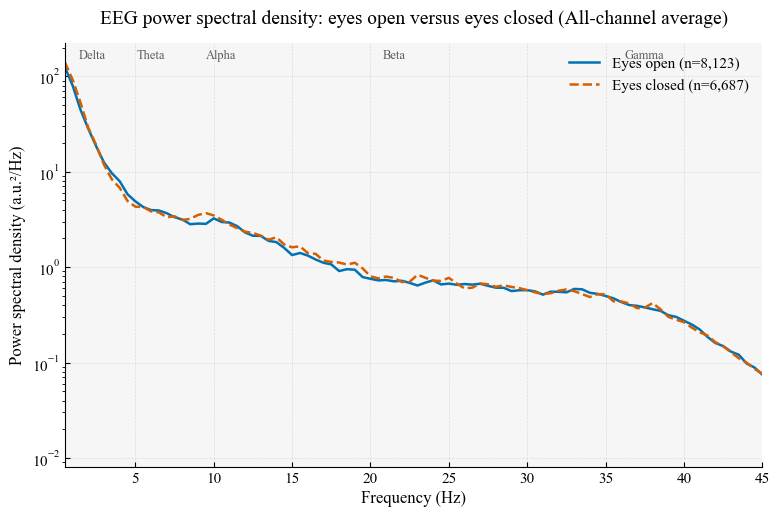

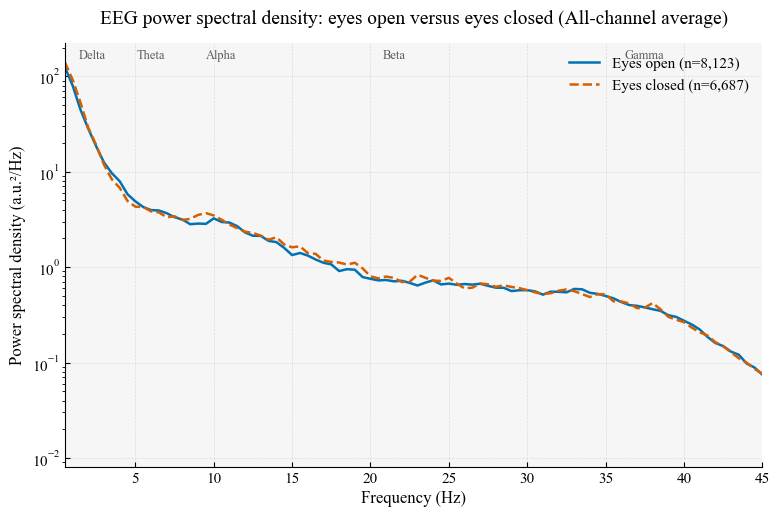

In [7]:
def plot_psd_comparison(result, channel_label='All-channel average', output_path=None):
    """Plot the eyes-open versus eyes-closed PSD comparison."""
    fig, ax = plt.subplots(figsize=(9, 5.5))

    for state in sorted(result):
        info = result[state]
        linestyle = '-' if state == 0 else '--'
        ax.semilogy(
            info['freqs'], info['psd'],
            color=STATE_COLORS[state], linestyle=linestyle, linewidth=1.8,
            label=f"{STATE_LABELS[state]} (n={info['n']:,})",
        )

    for name, (low, high) in BANDS.items():
        ax.axvspan(low, high, color='gray', alpha=0.07, linewidth=0)
        ax.text((low + high) / 2, 0.985, name,
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=9, color='0.35')

    ax.set_title(f'EEG power spectral density: eyes open versus eyes closed ({channel_label})',
                 fontsize=14, pad=14)
    ax.set_xlabel('Frequency (Hz)', fontsize=12)
    ax.set_ylabel('Power spectral density (a.u.²/Hz)', fontsize=12)
    ax.set_xlim(0.5, 45.0)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.35)
    ax.tick_params(labelsize=11, direction='in')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='upper right', frameon=False, fontsize=11)

    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches='tight')
    if plt.get_backend().lower() != 'agg':
        plt.show()
    return fig


plot_psd_comparison(result_all, output_path='eeg_eye_state_psd_notebook.png')

## Result Interpretation

The results show that Delta-band low-frequency power around 1-2 Hz is markedly higher with eyes closed than with eyes open. Increased low-frequency slow activity is associated with relaxation, drowsiness, and reduced visual stimulation. The classical eyes-closed alpha enhancement is not evident in this dataset. The data are noisy, contain many artifacts, and were recorded at only 128 Hz, so the interpretation requires caution.

Further analyses may set the channel parameter to O1 or O2 to examine the occipital alpha rhythm, or re-estimate the PSD after adjusting the artifact threshold or applying 1-40 Hz band-pass filtering.